In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Credit Card Fraud Detection.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.shape)

(41683, 31)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41683 entries, 0 to 41682
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    41683 non-null  int64  
 1   V1      41683 non-null  float64
 2   V2      41683 non-null  float64
 3   V3      41682 non-null  float64
 4   V4      41682 non-null  float64
 5   V5      41682 non-null  float64
 6   V6      41682 non-null  float64
 7   V7      41682 non-null  float64
 8   V8      41682 non-null  float64
 9   V9      41682 non-null  float64
 10  V10     41682 non-null  float64
 11  V11     41682 non-null  float64
 12  V12     41682 non-null  float64
 13  V13     41682 non-null  float64
 14  V14     41682 non-null  float64
 15  V15     41682 non-null  float64
 16  V16     41682 non-null  float64
 17  V17     41682 non-null  float64
 18  V18     41682 non-null  float64
 19  V19     41682 non-null  float64
 20  V20     41682 non-null  float64
 21  V21     41682 non-null  float64
 22

In [6]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [7]:
print(df['Class'].value_counts())

Class
0.0    41574
1.0      108
Name: count, dtype: int64


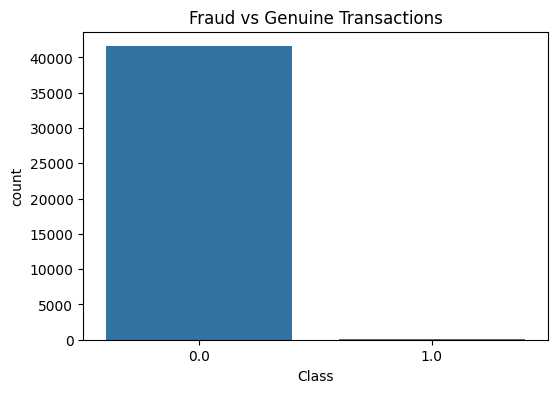

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()

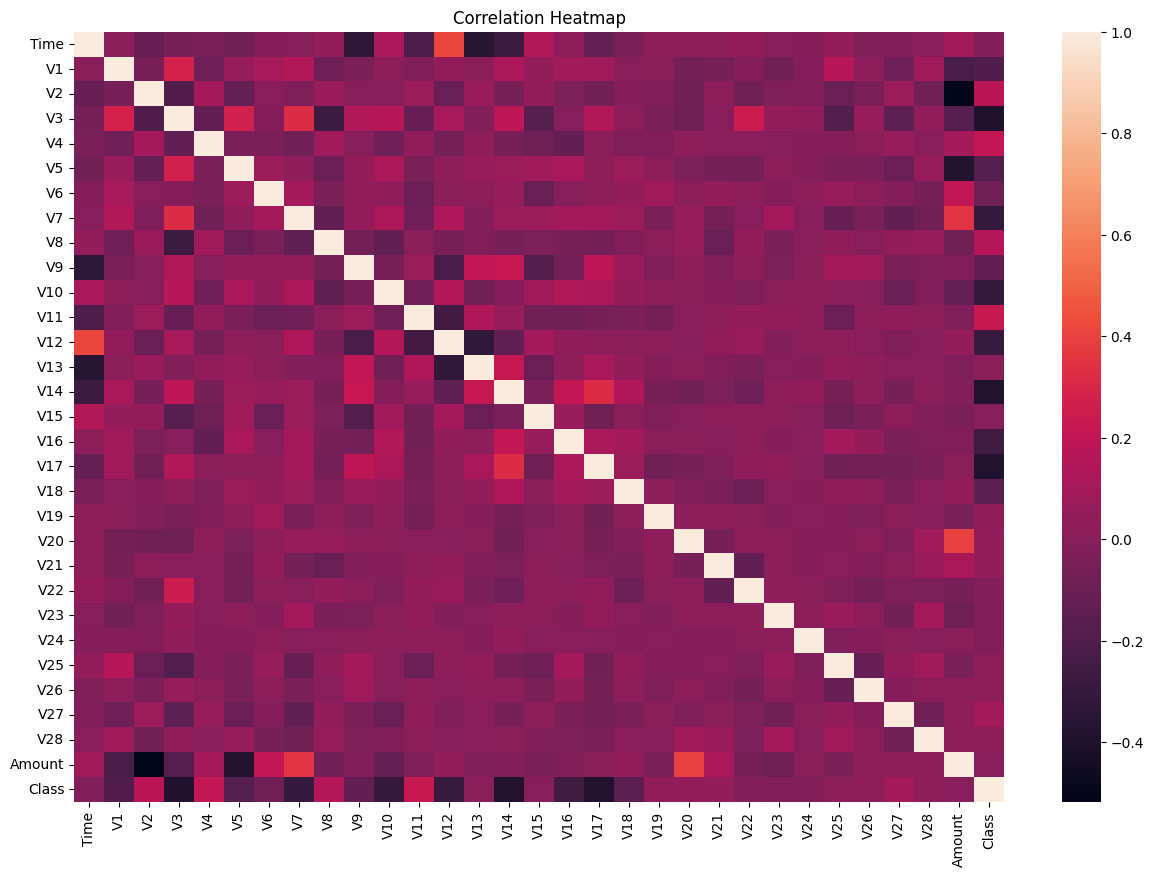

In [9]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr())

plt.title("Correlation Heatmap")

plt.show()

In [17]:
# Remove rows with missing target value
df = df.dropna(subset=['Class'])

# Verify
print(df['Class'].isnull().sum())

0


In [21]:
X = df.drop('Class', axis=1)
y = df['Class']

In [22]:
print(df['Class'].dtype)
print(df['Class'].unique()[:20])
print(df['Class'].value_counts())

float64
[0. 1.]
Class
0.0    41574
1.0      108
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [23]:
predictions = model.predict(X_test)

print(predictions[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy =", accuracy)

Accuracy = 0.9990404222142257


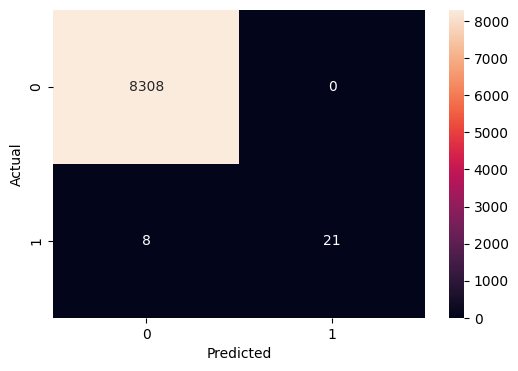

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8308
         1.0       1.00      0.72      0.84        29

    accuracy                           1.00      8337
   macro avg       1.00      0.86      0.92      8337
weighted avg       1.00      1.00      1.00      8337



In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

   Feature  Importance
12     V12    0.134354
14     V14    0.122915
17     V17    0.120098
9       V9    0.095635
26     V26    0.060357
4       V4    0.060297
10     V10    0.049753
16     V16    0.045715
11     V11    0.041045
3       V3    0.030191


In [28]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Genuine Transaction")

Prediction: 0.0
Genuine Transaction


In [29]:
import pickle

pickle.dump(
    model,
    open(
        "fraud_detection_model.pkl",
        "wb"
    )
)

print("Model Saved Successfully")

Model Saved Successfully
